In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", color_codes=True)

In [3]:
import pandas as pd
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets = ['OAT', 'AIMHIGH', 'PEACE', 'SPRINT', 'ACCORD', 'BARI2D']
outcomes = ['comb', 'Primary', 'PRIMARY', 'PRIMARY','','']
locations = ['datasets/OAT/Ancillary/', 'datasets/AIMHIGH/', 'datasets/PEACE/Data/', 'datasets/SPRINT_POP/Datasets/', 
            'datasets/ACCORD/', 'datasets/']
intervention = ['Percutaneous coronary intervention', 'Niacin', 'Trandolapril', 'SBP target <120mm Hg', {'Intensive Glycemia', 'Intensive BP', 'Lipid Fibrate'}]

In [7]:
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/auton_survival/datasets/', outcome='', intervention='Lipid')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 18)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:756: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  visit_col='Visit',
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:757: S

In [ ]:
features.Baseline_Weight

In [2]:
from datasets_retrospective import load_bari_2d_dataset
outcomes, features, intervention, cat_feats, num_feats = load_bari_2d_dataset(location='/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/auton_survival/datasets/', outcome='', intervention='diabtrt')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:978: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1157: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'EP_CHD': outcomedt = 'DYCHD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1158: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'CANCER': outcomedt = 'DYCANC'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1159: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'GIBLEED': outcomedt = 'DYGIBLD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospe

(2368, 49)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:573: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes.event = outcomes.event == 1.0


In [3]:
features.Baseline_Height_CM

N4817    161.25
N2204    161.75
N3296    157.00
N4106    167.00
N3356    181.00
          ...  
N2768    174.00
N3935    163.20
N2351    147.50
N2462    160.25
N3801    160.00
Name: Baseline_Height_CM, Length: 2368, dtype: float64

In [30]:
len(cat_feats)+len(num_feats)

47

In [31]:
intervention

N4817      Insulin Providing
N2204    Insulin Sensitizing
N3296    Insulin Sensitizing
N4106      Insulin Providing
N3356    Insulin Sensitizing
                ...         
N2768      Insulin Providing
N3935    Insulin Sensitizing
N2351    Insulin Sensitizing
N2462    Insulin Sensitizing
N3801      Insulin Providing
Name: Glycemic_Arm_Treatment, Length: 2368, dtype: object

In [33]:
features['Cardiovascular_Treatment']

N4817            Medical Therapy
N2204            Medical Therapy
N3296            Medical Therapy
N4106            Medical Therapy
N3356            Medical Therapy
                  ...           
N2768            Medical Therapy
N3935    Early Revascularization
N2351            Medical Therapy
N2462    Early Revascularization
N3801    Early Revascularization
Name: Cardiovascular_Treatment, Length: 2368, dtype: object

In [34]:
outcomes

,time,event
N4817,362.0,True
N2204,2175.0,False
N3296,1231.0,True
N4106,1465.0,False
N3356,412.0,True
...,...,...
N2768,2232.0,False
N3935,1465.0,False
N2351,1457.0,True
N2462,1460.0,False


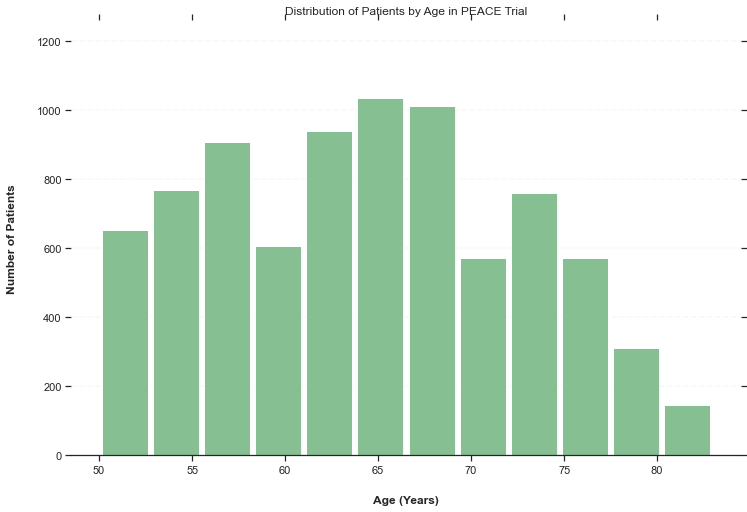

In [25]:
age_hist = features.hist(column='Baseline_Age', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

age_hist = age_hist[0]
for x in age_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Age in PEACE Trial")

    # Set x-axis label
    x.set_xlabel("Age (Years)", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

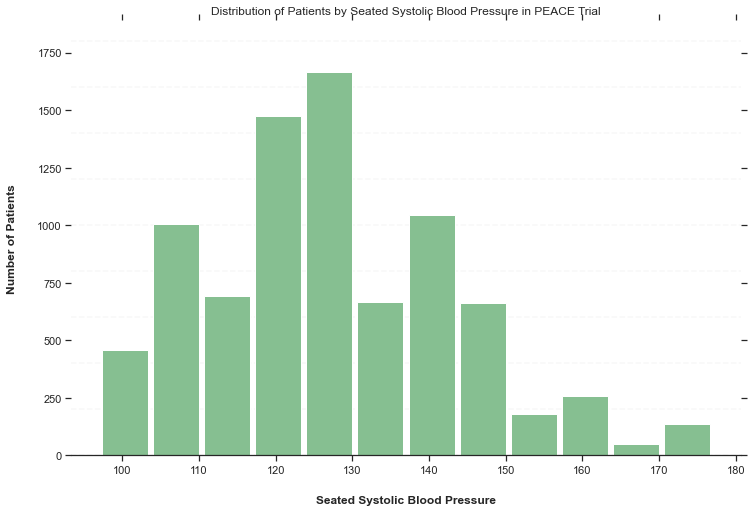

In [26]:
SBP_hist = features.hist(column='Baseline_Seated_Systolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

SBP_hist = SBP_hist[0]
for x in SBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Systolic Blood Pressure in PEACE Trial")

    # Set x-axis label
    x.set_xlabel("Seated Systolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

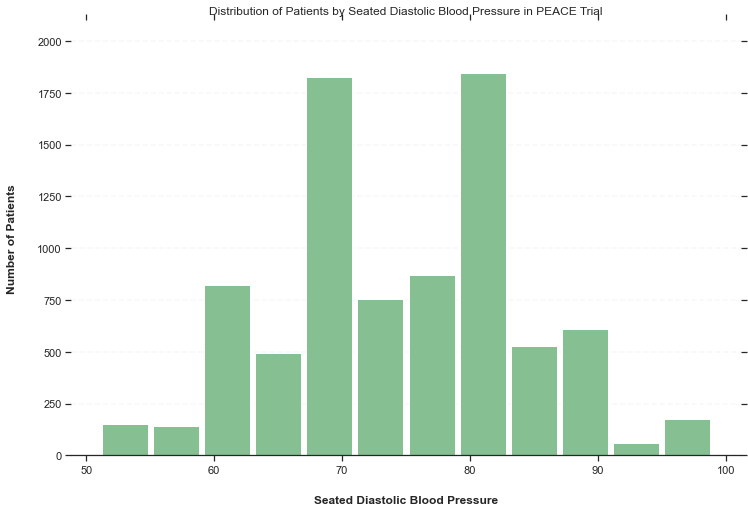

In [28]:
DBP_hist = features.hist(column='Baseline_Seated_Diastolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

DBP_hist = DBP_hist[0]
for x in DBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Diastolic Blood Pressure in PEACE Trial")

    # Set x-axis label
    x.set_xlabel("Seated Diastolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

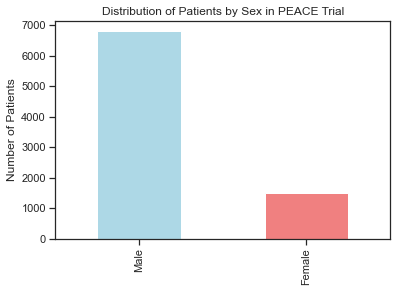

In [31]:
features['Sex'].value_counts().plot(kind="bar", title="Distribution of Patients by Sex in PEACE Trial", color=['lightblue', 'lightcoral'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

In [166]:
cat_feats=['Sex', 'Baseline_Smoke_status', 'Baseline_History_Insulin']
num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [167]:
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [153]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [160]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features, outcomes.time, outcomes.event, intervention=='Trandolapril', vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

 79%|███████▉  | 79/100 [00:27<00:07,  2.84it/s]


In [161]:
zeta_probs = model.predict_latent_phi(features)
zeta =  np.argmax(zeta_probs, axis=1)
idx_list_0 = np.where(zeta == 0)
idx_list_1 = np.where(zeta == 1)

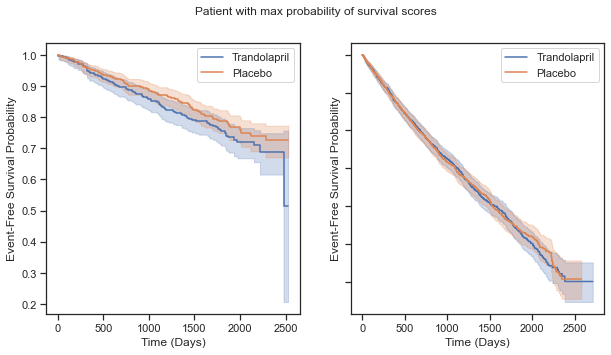

In [162]:
from auton_survival import reporting
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

In [80]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_train, x_test, y_train, y_test = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Trandolapril'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 5803
Number of test data points: 2487


In [81]:
x_tr = x_train
t_tr = y_train['time']
e_tr = y_train['event']
a_tr = intervention[y_train.index]=='Trandolapril'
x_te = x_test
t_te = y_test['time']
e_te = y_test['event']
a_te = intervention[y_test.index]=='Trandolapril'

In [82]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:23<00:00,  4.33it/s]


In [83]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
idx_list_0 = np.where(zeta_train == 0)
idx_list_1 = np.where(zeta_train == 1)
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

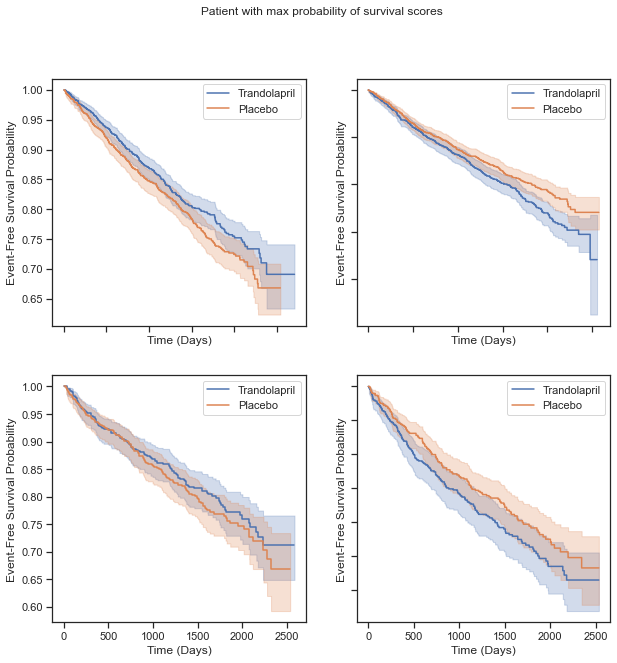

In [84]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize= (10, 10))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(y_train.iloc[idx_list_0], a_tr.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_1], a_tr.iloc[idx_list_1], ax=ax2)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_0te], a_te.iloc[idx_list_0te], ax=ax3) 
reporting.plot_kaplanmeier(y_test.iloc[idx_list_1te], a_te.iloc[idx_list_1te], ax=ax4)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()
# First row is training data
# Second row is test data

SPRINT

In [61]:
from datasets_retrospective import load_sprint_dataset
outcomes, features, intervention, cat_feats, num_feats = load_sprint_dataset(location='datasets/SPRINT_POP/Datasets/', outcome='PRIMARY')

(9361, 27)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intervention[intervention == 1.0] = 'SBP target <120mm Hg'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:117: SettingWithCopyWar

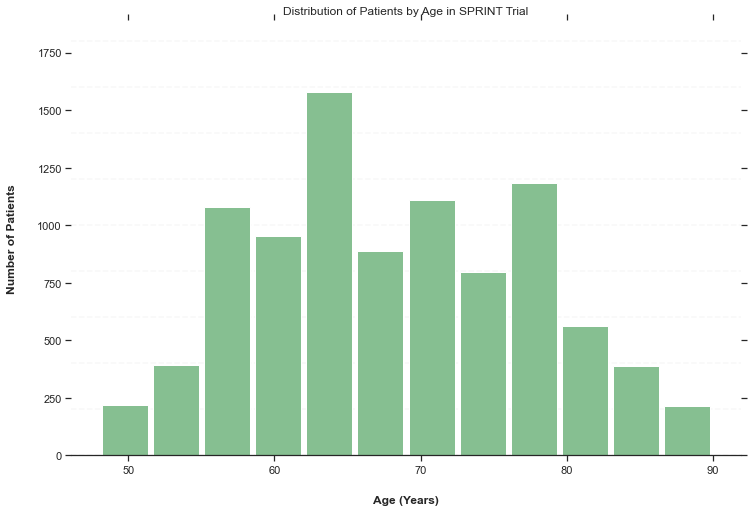

In [9]:
age_hist = features.hist(column='Baseline_Age', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

age_hist = age_hist[0]
for x in age_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Age in SPRINT Trial")

    # Set x-axis label
    x.set_xlabel("Age (Years)", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

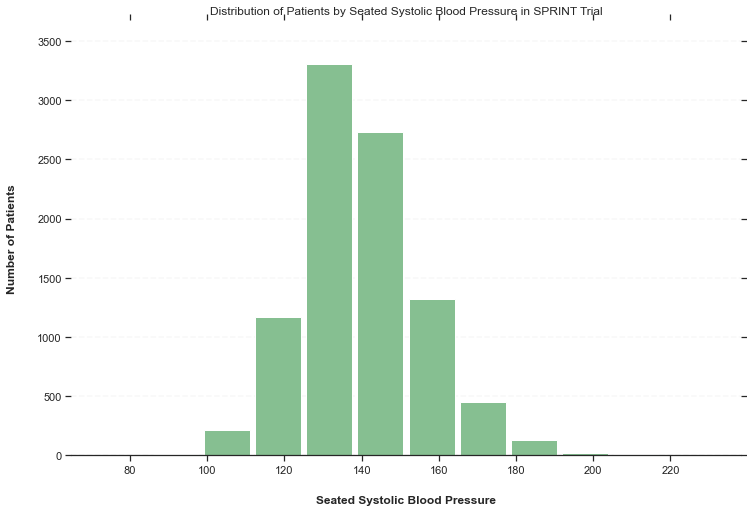

In [11]:
SBP_hist = features.hist(column='Baseline_Seated_Systolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

SBP_hist = SBP_hist[0]
for x in SBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Systolic Blood Pressure in SPRINT Trial")

    # Set x-axis label
    x.set_xlabel("Seated Systolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

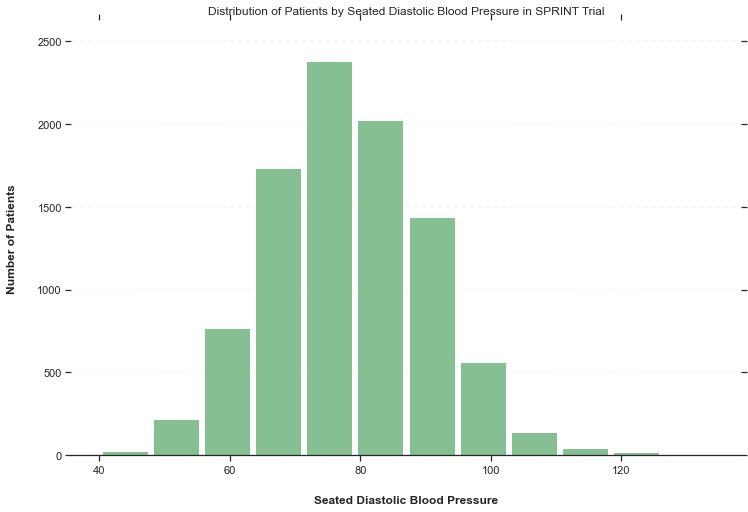

In [12]:
DBP_hist = features.hist(column='Baseline_Seated_Diastolic_Blood_Pressure', bins=12, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)

DBP_hist = DBP_hist[0]
for x in DBP_hist:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("Distribution of Patients by Seated Diastolic Blood Pressure in SPRINT Trial")

    # Set x-axis label
    x.set_xlabel("Seated Diastolic Blood Pressure", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Number of Patients", labelpad=20, weight='bold', size=12)

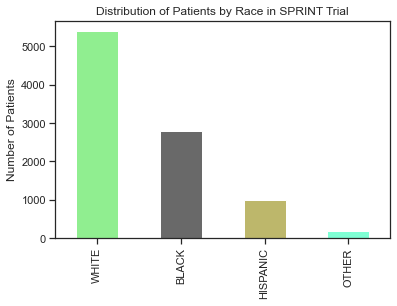

In [14]:
features['Race'].value_counts().plot(kind="bar", title="Distribution of Patients by Race in SPRINT Trial", color=['lightgreen', 'dimgray', 'darkkhaki', 'aquamarine'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

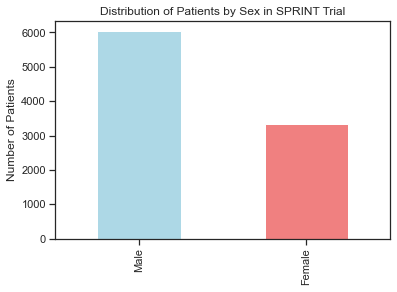

In [15]:
features['Sex'].value_counts().plot(kind="bar", title="Distribution of Patients by Sex in SPRINT Trial", color=['lightblue', 'lightcoral'])
# plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

In [62]:
cat_feats=['Sex', 'Race', 'Baseline_On_Statin']
num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [63]:
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [8]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [64]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features, outcomes.time, outcomes.event, intervention=='SBP target <120mm Hg', vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:38<00:00,  2.62it/s]


In [65]:
zeta_probs = model.predict_latent_phi(features)
zeta =  np.argmax(zeta_probs, axis=1)
idx_list_0 = np.where(zeta == 0)
idx_list_1 = np.where(zeta == 1)

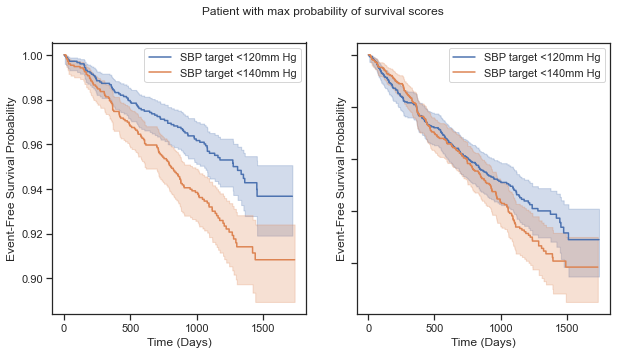

In [66]:
from auton_survival import reporting
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_0], intervention.iloc[idx_list_0], ax=ax1)
reporting.plot_kaplanmeier(outcomes.iloc[idx_list_1], intervention.iloc[idx_list_1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['SBP target <120mm Hg', 'SBP target <140mm Hg'], loc="upper right")
plt.show()